#Finansta Yapay Zeka

##Finans için Uygun Makine Öğrenmesi Modelleri
- Lojistik regresyon, fiyatın yönünü tahmin eden ikili sınıflandırma problemlerinde etkili bir yöntemdir.
- Karar ağaçları, finansal verilerdeki karmaşık ilişkileri sezgisel olarak modelleyebilir.
- Random Forest, çoklu ağaç yapısı sayesinde daha stabil ve güvenilir tahminler üretir.

## Finansal Tahmin Senaryoları
- Fiyat tahmini, regresyon modelleriyle sürekli değer üreten analitik bir süreçtir
- Trend tahmini, piyasanının yukarı mı aşağı mı hareket edeceğini belirlemek için sınıflandırma modelleri gerektirir.
- Risk skoru hesaplaması, müşteri veya işlem davranışlarını analiz eden AI tabanlı segmentasyon modelleriyle yapılabilir.

## Model Başarısının Ölçülmesi
- MAE ve RMSE, regresyon modellerinde tahmin hatasının büyüklüğünü ölçen kritik metriklerdir.
- Accuracy ve precision, sınıflandırma modellerinin doğru tahmin yapma gücünü değerlendirir.
- Backtesting, modellerin geçmiş veride nasıl performans gösterdiğini ortaya koyan finans dünyasına özel bir test yöntemidir.

# Enerji Tüketimi Tahmini (Energy Consumption Forecasting)

- Bu projenin amacı, bir yapının (ev,bina veya tesis) saatlik enerji tüketimini makine öğrenmesi yöntemi kullanarak tahmin etmektir.
- Enerji tahmini, finansal planlama, bütçe yönetimi, operasyonel verimlilik ve talep tahmini gibi ktritik alanlarda kullanılan temel analizlerden bir tanesidir.

- Veri seti: household power consumption dataset
  - https://www.kaggle.com/datasets/imtkaggleteam/household-power-consumption?resource=download$0
- Veri alanları:
  - date: ölçüm tarihi
  - time: ölçüm tarihi
  - global_active_power : aktif enerji tüketimi (kW)
  - reaktif güç, voltage, sub metering ...


Ana başlıklar:
- Feature Engineering (Öznitelik Mühendisliği)
- Veri temizleme
- Makine öğrenmesi yöntemi ile training
- Değerlendirme (testing)

Akış şeması:
1. Veri hazırlama:
  - csv dosyasını yükleme
  - date + time objesini birleştir
  - sayısallaştırma ve eksik değer doldurma
  - negatif değerleri düzeltme
2. Öznitelik Mühendisliği
  - saatlik, günlük, haftalık ve aylık özellikleri ekle
  - lag ekleme, 1 saatlik ve 24 saatlik
  - roll 24 saatlik ve 7
  - nan satırların temizlenmesi
3. Model Eğitimi
  - train test split
  - standart scaler ile normalizasyon
  - random forest regressor modelinin eğitilmesi
4. Tahmin ve Değerlendirme
  - test verisi üzerinde tahmin yapma
  - rmse (root mean squared error) ile değerlendirme yapma
  - gerçek vs tahmin çizgisel grafiklerin çizilmesi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error # değerlendirme metriği
from sklearn.model_selection import train_test_split # veri setinin eğitim ve test verisine bölmek için
from sklearn.preprocessing import StandardScaler # normalizasyon için
from sklearn.ensemble import RandomForestRegressor # makine öğrenmesi algoritması

## Veri Setinin Yüklenmesi ve Temizlenmesi
- date ve time birleştir
- global active power sütununu al
- gereksiz featureları temizle
- eksik değerleri doldur
- negatif değerleri sıfırla

In [3]:
# veri setini yükle
df = pd.read_csv("/content/sample_data/household_power_consumption.csv")
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [5]:
# date ile timeı birleştirme
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df = df.sort_values("Datetime").reset_index(drop=True)
df.head()

/tmp/ipykernel_5146/2262214640.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0,2006-12-16 17:28:00


In [6]:
# sadece enerji tüketim kolonunu al
df["Energy"] = df["Global_active_power"]

In [7]:
# gereksiz kolonları sil
df = df[["Datetime","Energy"]]
df.head()

,Datetime,Energy
0,2006-12-16 17:24:00,4.216
1,2006-12-16 17:25:00,5.36
2,2006-12-16 17:26:00,5.374
3,2006-12-16 17:27:00,5.388
4,2006-12-16 17:28:00,3.666


In [8]:
# veri temizliği
# sayısal olmayan değerleri nan a çevir
df["Energy"] = pd.to_numeric(df["Energy"],errors = "coerce")

In [9]:
df["Energy"] = df["Energy"].interpolate(method="linear")

In [11]:
# negatif değer varsa sıfır yap çünkü enerji tüketimi negatif olamaz
df["Energy"] = df["Energy"].apply(lambda x: max(x,0))
df.head()

,Datetime,Energy
0,2006-12-16 17:24:00,4.216
1,2006-12-16 17:25:00,5.360
2,2006-12-16 17:26:00,5.374
3,2006-12-16 17:27:00,5.388
4,2006-12-16 17:28:00,3.666


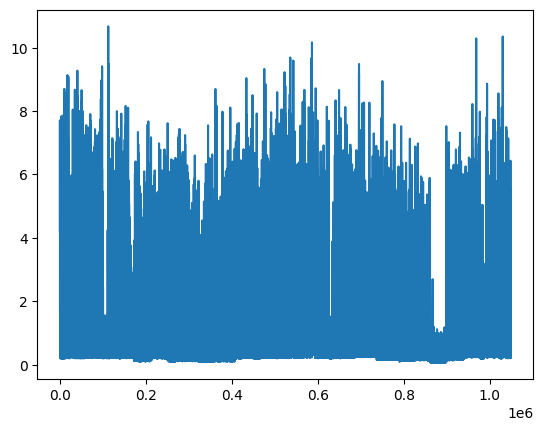

In [12]:
plt.plot(df["Energy"])

In [13]:
# veri uzunluğu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 2 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   Datetime  1048575 non-null  datetime64[ns]
 1   Energy    1048575 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 16.0 MB


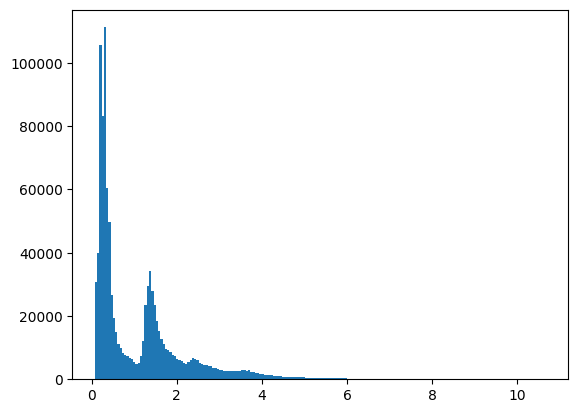

In [15]:
plt.hist(df["Energy"],bins=200)
plt.show()